#Download the dataset form github

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
      housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

#Download the dataset form local disk

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import pandas as pd
path = '/content/drive/MyDrive/ml/datasets/'
housing = pd.read_csv(path + 'housing.csv', header='infer')

Mounted at /content/drive


#Look at the Data Structure

In [4]:
# Wyświetla 5 pierwszych wierszy, żeby zobaczyć nazwy kolumn i przykładowe wartości
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print(f"Number of samples: {housing.shape[0]}")
print(f"Number of features: {housing.shape[1]}")

# Wyświetla podsumowanie techniczne: typy danych (float, object) i liczbę brakujących wartości (Non-Null)
print("\nDataset information:")
housing.info()

Number of samples: 20640
Number of features: 10

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#Check the distribution of categories for ocean proximity

In [6]:
# value_counts pokazuje, ile mamy unikalnych kategorii w danej kolumnie (np. odległość od oceanu)
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [7]:
housing["ocean_proximity"].value_counts(normalize=True)

,proportion
ocean_proximity,
<1H OCEAN,0.442636
INLAND,0.317393
NEAR OCEAN,0.128779
NEAR BAY,0.110950
ISLAND,0.000242


#Summary of numeric features

In [8]:
# Pokazuje statystyki opisowe: średnią, odchylenie standardowe, min/max oraz kwartyle.
# Pomaga wykryć wartości odstające (outliers).
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#Histogram of numeric features

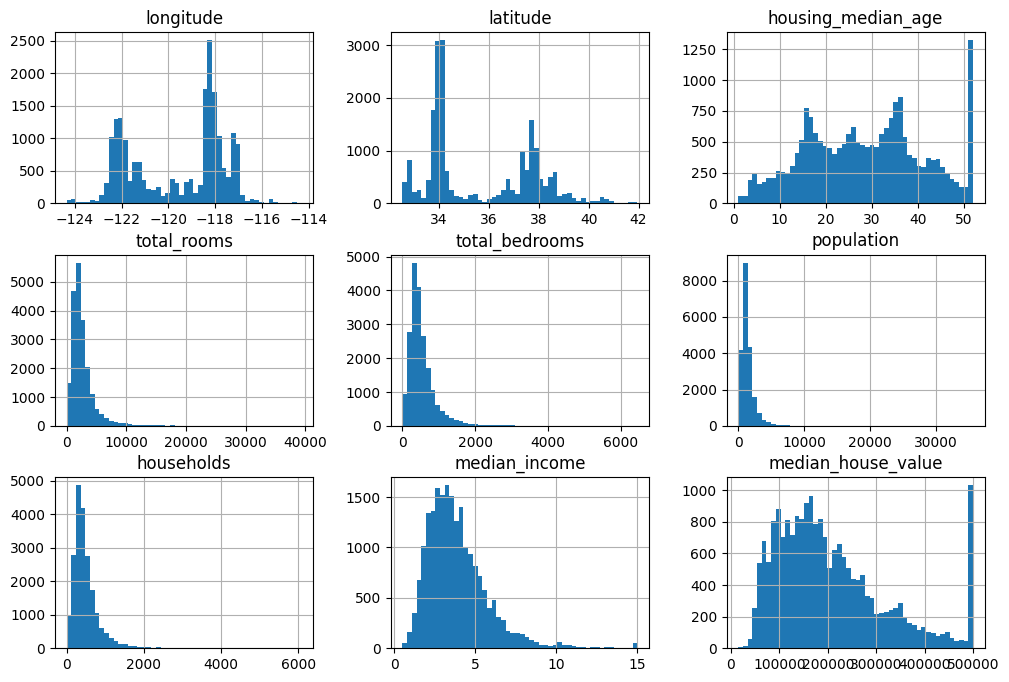

In [9]:
import matplotlib.pyplot as plt
# Rysujemy histogramy dla wszystkich cech numerycznych.
# bins=50 zwiększa dokładność słupków, figsize ustala rozmiar wykresów.
housing.hist(bins=50, figsize=(12,8))
plt.show()

#Check correlation

In [10]:
# Obliczamy korelację Persona (wartości od -1 do 1).
# 1 oznacza silny związek dodatni (rośnie jedno, rośnie drugie).
# -1 oznacza silny związek ujemny (rośnie jedno, maleje drugie).
corr_matrix = housing.drop("ocean_proximity", axis=1).corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


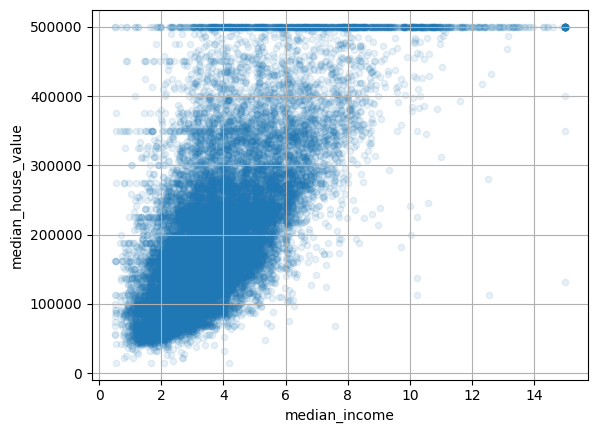

In [11]:
import matplotlib.pyplot as plt

#Wybieramy median_income jako bazę do podziału warstwowego,
#analiza korelacji wykazała, że jest to cecha najsilniej powiązana z ceną nieruchomości.

# Wykres rozproszenia (Scatter plot) dla najsilniejszej cechy.
# alpha=0.1 sprawia, że punkty są półprzezroczyste (widzimy, gdzie jest największe zagęszczenie).
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

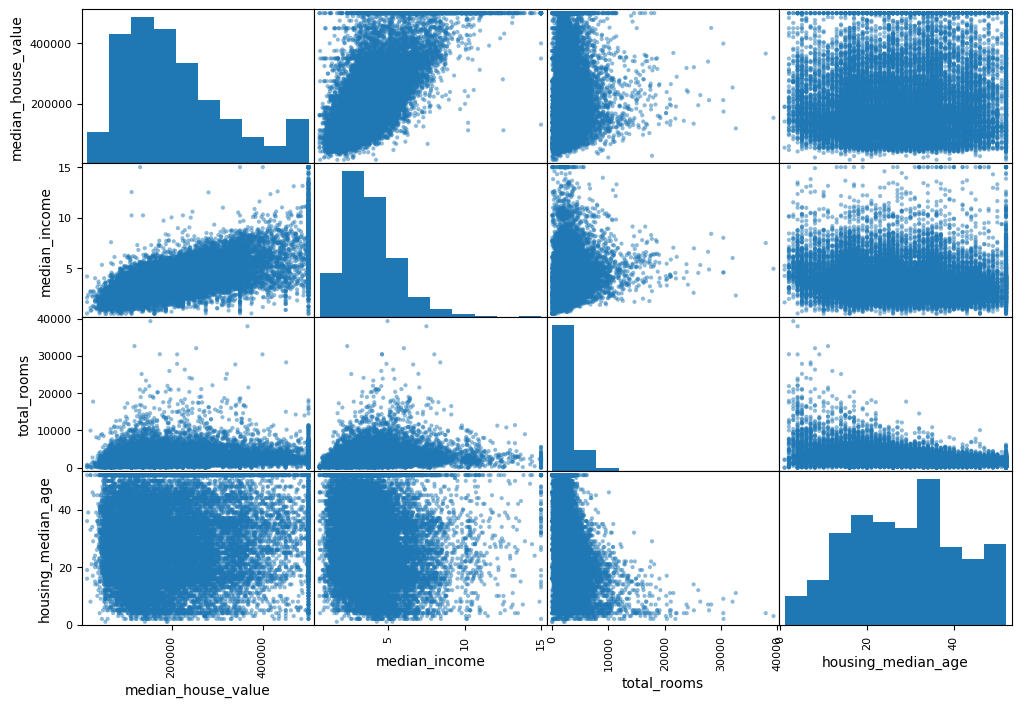

In [12]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

#Create a Test Set

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Tworzymy pomocniczą kolumnę "income_cat".
# Używamy pd.cut, aby zamienić ciągłe zarobki na 5 grup (kategorii).
# Robimy to, bo chcemy, żeby zbiór testowy miał takie same proporcje osób
# biednych/bogatych co zbiór oryginalny (unikamy błędu statystycznego).
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# 2. Wykonujemy właściwy podział warstwowy (Stratified Split).
# test_size=0.2 oznacza, że 20% danych idzie do testu, a 80% do treningu.
# stratify=housing["income_cat"] to kluczowy parametr - pilnuje równych proporcji dochodów.
# random_state=42 zapewnia, że za każdym razem gdy uruchomisz kod, podział będzie identyczny.
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

# 3. Sprawdzamy brakujące wartości (NaN) w kolumnie "total_bedrooms".
# Teraz zobaczysz, że braki rozłożyły się proporcjonalnie (np. ok. 158 w treningowym i 49 w testowym),
# co potwierdza, że podział zadziałał poprawnie i losowo.
print(f"Całość: {len(housing)}")
print(f"Treningowy: {len(strat_train_set)}")
print(f"Testowy: {len(strat_test_set)}")

Całość: 20640
Treningowy: 16512
Testowy: 4128


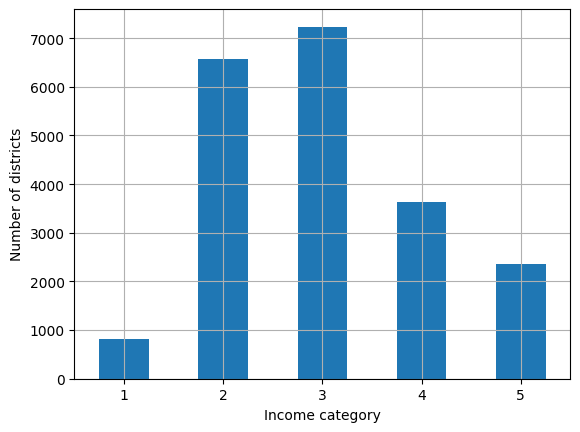

In [14]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [15]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [16]:
# 1. Funkcja pomocnicza, która liczy jaki procent zbioru stanowią poszczególne kategorie dochodów.
# Wynik to np. "Kategoria 3 stanowi 35% całego zbioru".
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

# 2. Tworzymy dla porównania zwykły, całkowicie losowy podział (bez parametru stratify).
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# 3. Tworzymy tabelę zbiorczą (DataFrame), która zestawia ze sobą trzy wyniki:
compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),        # Proporcje w CAŁYM zbiorze (ideał)
    "Stratified %": income_cat_proportions(strat_test_set), # Proporcje po inteligentnym podziale
    "Random %": income_cat_proportions(test_set),        # Proporcje po zwykłym losowaniu
}).sort_index()

# 4. Obliczamy błąd procentowy (o ile procent dany podział różni się od oryginału).
# Błąd Stratified % vs Overall % (powinien być bardzo bliski zeru).
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)

# Błąd Random % vs Overall % (zazwyczaj jest dużo większy).
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)

# 5. Wyświetlamy tabelę zamieniając ułamki na czytelne procenty i zaokrąglając do 2 miejsc.
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
income_cat,,,,,
1,3.98,4.00,4.02,0.36,0.97
2,31.88,31.88,32.44,-0.02,1.73
3,35.06,35.05,35.85,-0.01,2.27
4,17.63,17.64,16.74,0.03,-5.06
5,11.44,11.43,10.95,-0.08,-4.32


In [17]:
# 4. Usuwamy kolumnę "income_cat" z obu zbiorów.
# Była nam potrzebna tylko do sprawiedliwego podziału.
# Model nie powinien jej widzieć podczas nauki, bo to tylko nasza modyfikacja.
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

#Make copy of train set

In [18]:
#kopia zbioru treningowego
housingTrainSet = strat_train_set.copy()

#Visualize data

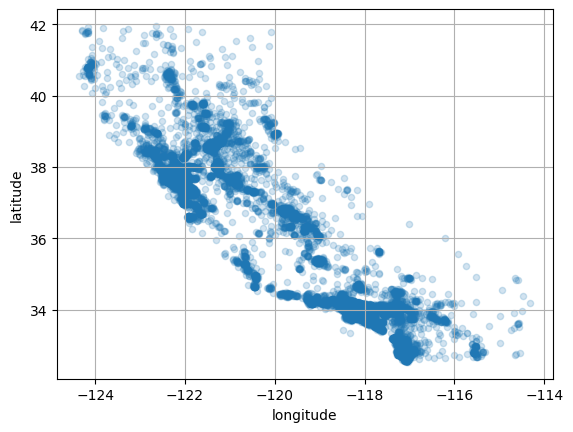

In [19]:
#wizulizacja geograficzna
#dzięki alpha widac zagęszczenie
housingTrainSet.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

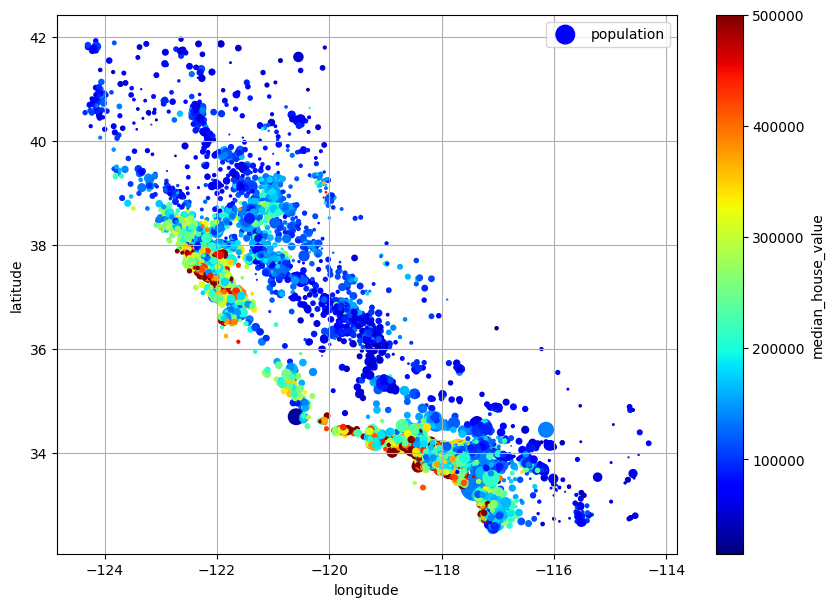

In [20]:
#wizulizacja geograficzna
#c = ceny mieszkań
#s = promień symbolizuje wielkość populacji
from matplotlib import legend
housingTrainSet.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housingTrainSet['population'] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10,7))

#Widac korelacje cen mieszkań z odległością od oceanu
plt.show()

#Experimenting with features correlation

In [21]:
# EKSPERYMENTOWANIE Z NOWYMI ATRYBUTAMI (Feature Engineering)
# Same liczby pokoi czy sypialni niewiele mówią. Blok może mieć 1000 pokoi, a domek 5.
# Dlatego tworzymy wskaźniki (proporcje), które są dużo lepsze dla modelu ML.

# 1. Ile średnio pokoi przypada na jedno gospodarstwo domowe w danej dzielnicy?
housingTrainSet["rooms_per_house"] = housingTrainSet["total_rooms"] / housingTrainSet["households"]

# 2. Jaki procent wszystkich pokoi stanowią sypialnie? (Mniejszy % może oznaczać domy o wyższym standardzie)
housingTrainSet["bedrooms_ratio"] = housingTrainSet["total_bedrooms"] / housingTrainSet["total_rooms"]

# 3. Ile osób średnio mieszka w jednym domu?
housingTrainSet["people_per_house"] = housingTrainSet["population"] / housingTrainSet["households"]

In [22]:
# SPRAWDZANIE KORELACJI PO DODANIU NOWYCH CECH
# Opcja numeric_only=True jest kluczowa, bo zapobiega błędom przy próbie
# liczenia korelacji dla tekstu (np. dla "ocean_proximity").
corr_matrix = housingTrainSet.corr(numeric_only=True)

# Sortujemy wyniki od najwyższych do najniższych względem ceny domu.
# Szukamy wartości bliskich 1 (silny wpływ dodatni) lub bliskich -1 (silny wpływ ujemny).
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
rooms_per_house,0.146255
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
people_per_house,-0.021991
population,-0.026882
longitude,-0.047466


#Clean up data

In [23]:
#kopia na orginalnym train set bez etykiet
housingTrainSet = strat_train_set.drop("median_house_value", axis=1)
housingTrainLabels = strat_train_set["median_house_value"].copy()

In [24]:
#musimy zajać się brakującymi dnymymi w atrybucie total_bedrooms

#opcja 1 -> pozbyć się dystryktów z barkującymi danymi
#opcja 2 -> pozbyć się atrybutu
#opcja 3 -> usypełnić braki określoną wartością (zero, średnia, mediana itd)

#opcja 1 -> housingTrainSet.dropna(subset=["total_bedrooms"], inplace=True)

#opcja 2 -> housingTrainSet.drop("total_bedrooms", axis=1)

#opcja 3 (najmniej destrukcyjna) -> median = housingTrainSet["total_bedrooms"].median()


#korzystamy z klasy SimpleImputer przez zaletę przechowywania wrtości mediany dla każdej cechy
#możwie wstawianie brakujących warosći nie tylko w zbiorze uczącym, ale także walidacyjnym, testowym oraz nowo wprowadzonych danych.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

#kopia train set wyłącznie z warości numerycznych, żeby móc wyliczyć mediane
housingTrainSetNum = housingTrainSet.select_dtypes(include=[np.number])

#dopasowanie wystąpienią klasy Imputer do danych uczących za pomocą fit()
#"uczy sie" analiza wybranych kolumn i obliczenie mediany dla kazde z nich
imputer.fit(housingTrainSetNum)

SimpleImputer(strategy='median')

In [25]:
#klasa imputer obliczyla mediane i zachowala wynik w zmiennnej statistics_
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [26]:
housingTrainSetNum.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [27]:
#uzupełnienie brakujących wartości -> wynik to czyta tablica danych
X = imputer.transform(housingTrainSetNum)

In [28]:
#zamiana tablicy NumPy (bez nazw kolumn, indeksow wierszy, same liczby) na tabele DataFrame
#przywrocenie org nazwy kolumn i nmeracje wierszy
housingTrainSet_transformed = pd.DataFrame(X, columns=housingTrainSetNum.columns, index=housingTrainSetNum.index)

#Text and categorical attribute support

In [29]:
housing_cat = housingTrainSet[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN


In [30]:
#zamiana atrybutów tekstowych (kategorialnych w tym przypadku) na wartości numeryczne
#Problem: algorymy mogą zakładać, że liczby o zbliżonych wartośćiach oznaczają obiekty bardziej podobne do siebie niż liczby odległe.
#dobre gdy kategorie są uporządkowane (zły, przeciętny, dobry)
#błedne przy kategoraiach nieuporządkowanych (nazwy regionów).
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)



In [31]:
#pierwsze 8 zakodowanych wartości
housing_cat_encoded[:8]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [34]:
#możemy uzyskać listę kategorii za pomocą zmiennej categories_
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [36]:
#kodowanie gorącojedynkowe
#rozwiazuje podany wyżej problem
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)


In [37]:
#macierz rzadka -> zamiast trzymąć w pamięci tysiace zer przechowuje pozycje wartości niezerwoej (jedynki)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [38]:
#można zamienic w tablice NumPy
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [39]:
#można podejrzeć kategorie
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

#Scaling and transforming features